In [1]:
# Instructor Performance and Course Quality Evaluation on EduPro

## Project Objective
#The objective of this project is to evaluate instructor performance and course quality on the EduPro online education platform using data-driven analysis.

### Key Objectives
 # Analyze instructor performance
 # Evaluate course quality
 # Study experience vs instructor ratings
 # Study instructor rating vs course rating
 # Analyze expertise-wise performance
 # Analyze instructor impact on enrollments
 # Identify high-performing and low-performing instructors
 # Develop KPIs for instructor and course evaluation

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
import os
from google.colab import files

file_name = 'EduPro Online Platform.xlsx'

if not os.path.exists(file_name):
    uploaded = files.upload(file_name)
    print(f"File '{file_name}' uploaded successfully.")
else:
    print(f"File '{file_name}' already exists. Skipping upload.")
    # If 'uploaded' variable is used later, it might expect a dictionary of file names.
    # For simplicity, we can provide an empty dictionary or a placeholder.
    # Typically, after upload, the file is read from disk (e.g., using pandas),
    # so the content of 'uploaded' might not be strictly necessary if the file exists on disk.
    uploaded = {file_name: b''}

File 'EduPro Online Platform.xlsx' already exists. Skipping upload.


In [4]:
import pandas as pd

users = pd.read_excel('EduPro Online Platform.xlsx', sheet_name="Users")
teachers = pd.read_excel('EduPro Online Platform.xlsx', sheet_name="Teachers")
courses = pd.read_excel('EduPro Online Platform.xlsx', sheet_name="Courses")
transactions = pd.read_excel('EduPro Online Platform.xlsx', sheet_name="Transactions")

In [5]:
print("Users:", users.shape)
print("Teachers:", teachers.shape)
print("Courses:", courses.shape)
print("Transactions:", transactions.shape)

Users: (3000, 5)
Teachers: (60, 7)
Courses: (60, 8)
Transactions: (10000, 7)


In [6]:
print("Users Dataset")
display(users.head())

print("Teachers Dataset")
display(teachers.head())

print("Courses Dataset")
display(courses.head())

print("Transactions Dataset")
display(transactions.head())

Users Dataset


,UserID,UserName,Age,Gender,Email
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com
1,U00002,angela22,29,Female,hallrandy@hotmail.com
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com
3,U00004,fthornton,23,Female,christensencatherine@outlook.com
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com


Teachers Dataset


,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating
0,TC00001,Leonard Montgomery,44,Female,Cybersecurity,6,3.24
1,TC00002,Jill Day,32,Female,Digital Marketing,9,4.14
2,TC00003,Amber Torres,32,Male,Design,4,1.56
3,TC00004,Kristi Scott,34,Female,Machine Learning,9,4.39
4,TC00005,David Williams,34,Male,Finance,2,3.11


Courses Dataset


,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28


Transactions Dataset


,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042


In [7]:
print("Users Columns:")
print(users.columns.tolist())

print("\nTeachers Columns:")
print(teachers.columns.tolist())

print("\nCourses Columns:")
print(courses.columns.tolist())

print("\nTransactions Columns:")
print(transactions.columns.tolist())

Users Columns:
['UserID', 'UserName', 'Age', 'Gender', 'Email']

Teachers Columns:
['TeacherID', 'TeacherName', 'Age', 'Gender', 'Expertise', 'YearsOfExperience', 'TeacherRating']

Courses Columns:
['CourseID', 'CourseName', 'CourseCategory', 'CourseType', 'CourseLevel', 'CoursePrice', 'CourseDuration', 'CourseRating']

Transactions Columns:
['TransactionID', 'UserID', 'CourseID', 'TransactionDate', 'Amount', 'PaymentMethod', 'TeacherID']


In [8]:
print("Users Shape:", users.shape)
print("Teachers Shape:", teachers.shape)
print("Courses Shape:", courses.shape)
print("Transactions Shape:", transactions.shape)

Users Shape: (3000, 5)
Teachers Shape: (60, 7)
Courses Shape: (60, 8)
Transactions Shape: (10000, 7)


In [9]:
print("Teachers Data Types:")
print(teachers.dtypes)

print("\nCourses Data Types:")
print(courses.dtypes)

print("\nTransactions Data Types:")
print(transactions.dtypes)

Teachers Data Types:
TeacherID             object
TeacherName           object
Age                    int64
Gender                object
Expertise             object
YearsOfExperience      int64
TeacherRating        float64
dtype: object

Courses Data Types:
CourseID           object
CourseName         object
CourseCategory     object
CourseType         object
CourseLevel        object
CoursePrice       float64
CourseDuration    float64
CourseRating      float64
dtype: object

Transactions Data Types:
TransactionID              object
UserID                     object
CourseID                   object
TransactionDate    datetime64[ns]
Amount                    float64
PaymentMethod              object
TeacherID                  object
dtype: object


In [10]:
print("Missing Values in Users:")
print(users.isnull().sum())

print("\nMissing Values in Teachers:")
print(teachers.isnull().sum())

print("\nMissing Values in Courses:")
print(courses.isnull().sum())

print("\nMissing Values in Transactions:")
print(transactions.isnull().sum())

Missing Values in Users:
UserID      0
UserName    0
Age         0
Gender      0
Email       0
dtype: int64

Missing Values in Teachers:
TeacherID            0
TeacherName          0
Age                  0
Gender               0
Expertise            0
YearsOfExperience    0
TeacherRating        0
dtype: int64

Missing Values in Courses:
CourseID          0
CourseName        0
CourseCategory    0
CourseType        0
CourseLevel       0
CoursePrice       0
CourseDuration    0
CourseRating      0
dtype: int64

Missing Values in Transactions:
TransactionID      0
UserID             0
CourseID           0
TransactionDate    0
Amount             0
PaymentMethod      0
TeacherID          0
dtype: int64


In [11]:
print("Users duplicates:", users.duplicated().sum())
print("Teachers duplicates:", teachers.duplicated().sum())
print("Courses duplicates:", courses.duplicated().sum())
print("Transactions duplicates:", transactions.duplicated().sum())

Users duplicates: 0
Teachers duplicates: 0
Courses duplicates: 0
Transactions duplicates: 0


In [12]:
teachers.describe()

,Age,YearsOfExperience,TeacherRating
count,60.000000,60.000000,60.000000
mean,38.450000,6.283333,3.125000
std,7.703015,4.715972,0.949797
min,27.000000,1.000000,1.050000
25%,32.000000,3.000000,2.487500
50%,36.500000,6.000000,3.275000
75%,46.250000,8.000000,3.827500
max,50.000000,24.000000,4.970000


In [13]:
courses.describe()

,CoursePrice,CourseDuration,CourseRating
count,60.000000,60.000000,60.000000
mean,92.986333,27.632500,3.097833
std,153.601506,16.092578,1.171232
min,0.000000,1.200000,1.130000
25%,0.000000,14.500000,2.107500
50%,0.000000,28.505000,3.065000
75%,133.615000,43.012500,4.102500
max,490.900000,49.730000,4.940000


In [14]:
print("Teacher Rating Statistics:")
print(teachers["TeacherRating"].describe())

Teacher Rating Statistics:
count    60.000000
mean      3.125000
std       0.949797
min       1.050000
25%       2.487500
50%       3.275000
75%       3.827500
max       4.970000
Name: TeacherRating, dtype: float64


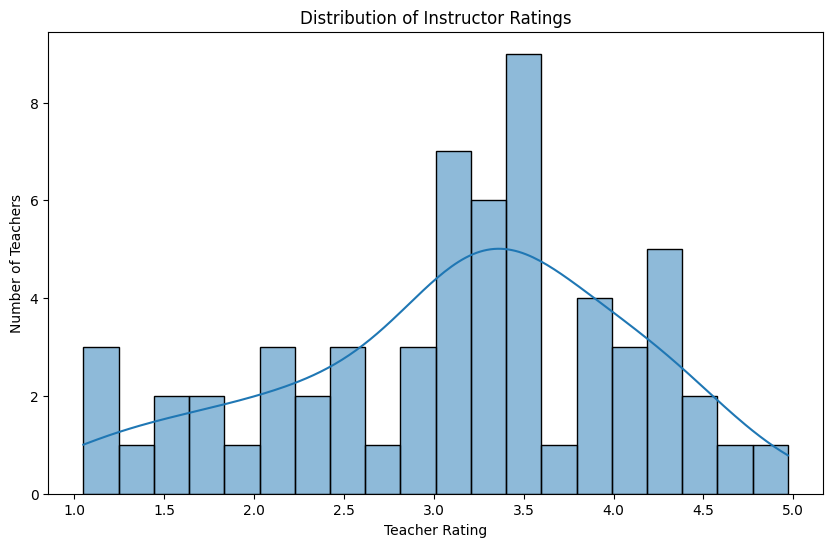

In [15]:
plt.figure(figsize=(10, 6))

sns.histplot(
    teachers["TeacherRating"],
    bins=20,
    kde=True
)

plt.title("Distribution of Instructor Ratings")
plt.xlabel("Teacher Rating")
plt.ylabel("Number of Teachers")
plt.show()

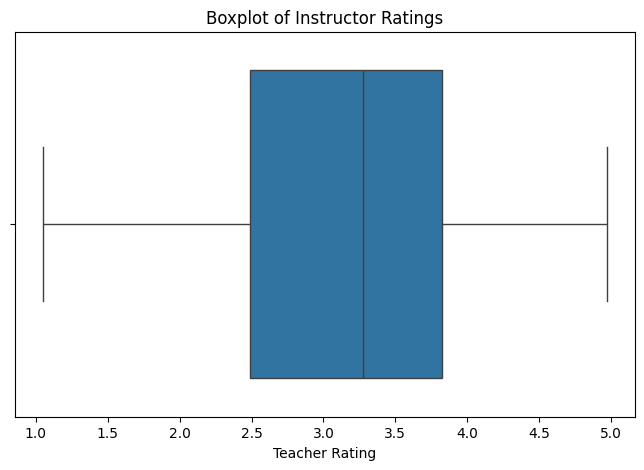

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=teachers["TeacherRating"])

plt.title("Boxplot of Instructor Ratings")
plt.xlabel("Teacher Rating")
plt.show()

In [17]:
top_teachers = teachers.sort_values(
    by="TeacherRating",
    ascending=False
).head(10)

display(
    top_teachers[
        ["TeacherID", "TeacherName", "Expertise",
         "YearsOfExperience", "TeacherRating"]
    ]
)

,TeacherID,TeacherName,Expertise,YearsOfExperience,TeacherRating
41,TC00042,Yolanda Levine,Machine Learning,21,4.97
39,TC00040,Kimberly Miller,Cybersecurity,24,4.58
3,TC00004,Kristi Scott,Machine Learning,9,4.39
36,TC00037,Debra Escobar,Finance,8,4.39
6,TC00007,Angela Beard,Machine Learning,6,4.36
52,TC00053,Aaron Kirby,Marketing,9,4.29
17,TC00018,Kari Pierce,Project Management,11,4.28
53,TC00054,Shelby Patrick,Artificial Intelligence,7,4.28
23,TC00024,Michael Kim,Digital Marketing,6,4.22
1,TC00002,Jill Day,Digital Marketing,9,4.14


In [18]:
display(
    teachers[
        ["TeacherName", "YearsOfExperience", "TeacherRating"]
    ].head(10)
)

,TeacherName,YearsOfExperience,TeacherRating
0,Leonard Montgomery,6,3.24
1,Jill Day,9,4.14
2,Amber Torres,4,1.56
3,Kristi Scott,9,4.39
4,David Williams,2,3.11
5,Rebecca Webb,14,3.36
6,Angela Beard,6,4.36
7,Steven Walker,15,3.54
8,Alexander Tucker,2,2.22
9,Frances Sanchez,1,2.18


In [19]:
correlation = teachers["YearsOfExperience"].corr(
    teachers["TeacherRating"]
)

print("Correlation between Experience and Teacher Rating:",
      round(correlation, 3))

Correlation between Experience and Teacher Rating: 0.598


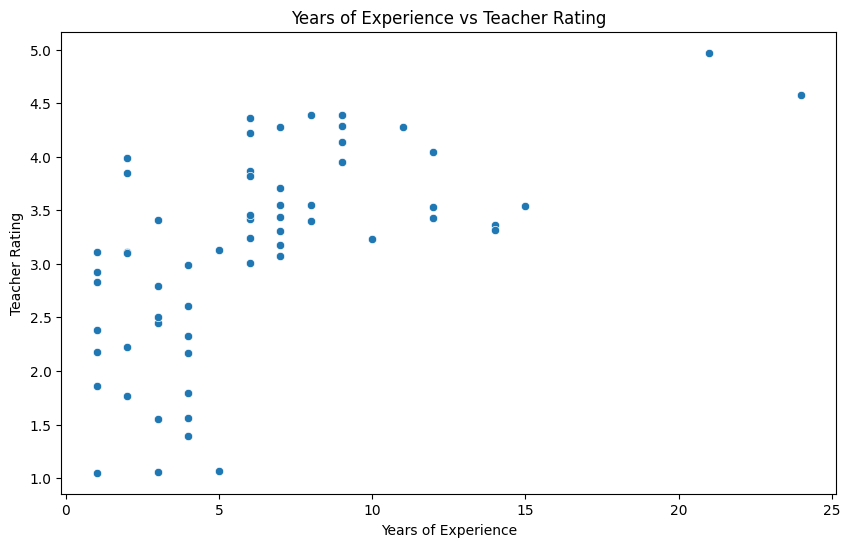

In [20]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=teachers,
    x="YearsOfExperience",
    y="TeacherRating"
)

plt.title("Years of Experience vs Teacher Rating")
plt.xlabel("Years of Experience")
plt.ylabel("Teacher Rating")
plt.show()

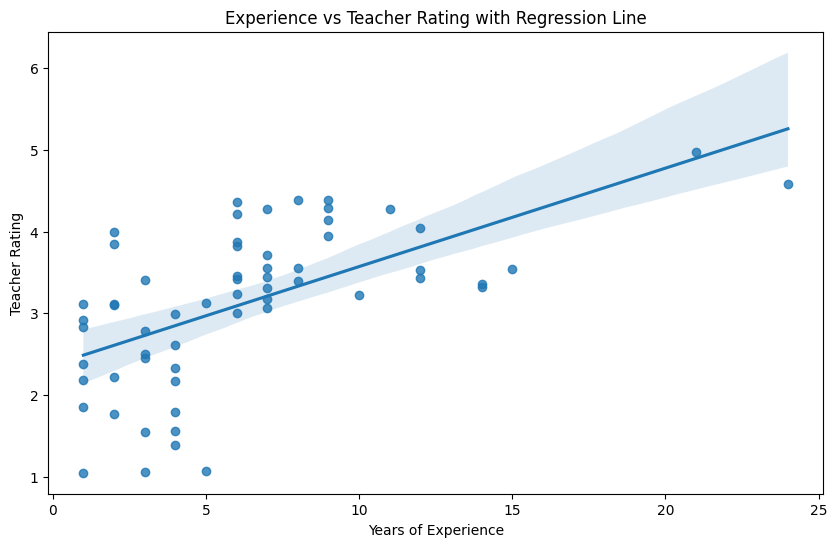

In [21]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=teachers,
    x="YearsOfExperience",
    y="TeacherRating"
)

plt.title("Experience vs Teacher Rating with Regression Line")
plt.xlabel("Years of Experience")
plt.ylabel("Teacher Rating")
plt.show()

In [22]:
def experience_group(years):
    if years <= 5:
        return "0-5 Years"
    elif years <= 10:
        return "6-10 Years"
    elif years <= 15:
        return "11-15 Years"
    else:
        return "16+ Years"

teachers["ExperienceGroup"] = teachers["YearsOfExperience"].apply(
    experience_group
)

In [23]:
experience_summary = (
    teachers
    .groupby("ExperienceGroup")["TeacherRating"]
    .agg(["count", "mean", "min", "max"])
    .reset_index()
)

experience_summary["mean"] = experience_summary["mean"].round(2)

display(experience_summary)

,ExperienceGroup,count,mean,min,max
0,0-5 Years,28,2.40,1.05,3.99
1,11-15 Years,7,3.64,3.32,4.28
2,16+ Years,2,4.78,4.58,4.97
3,6-10 Years,23,3.71,3.01,4.39


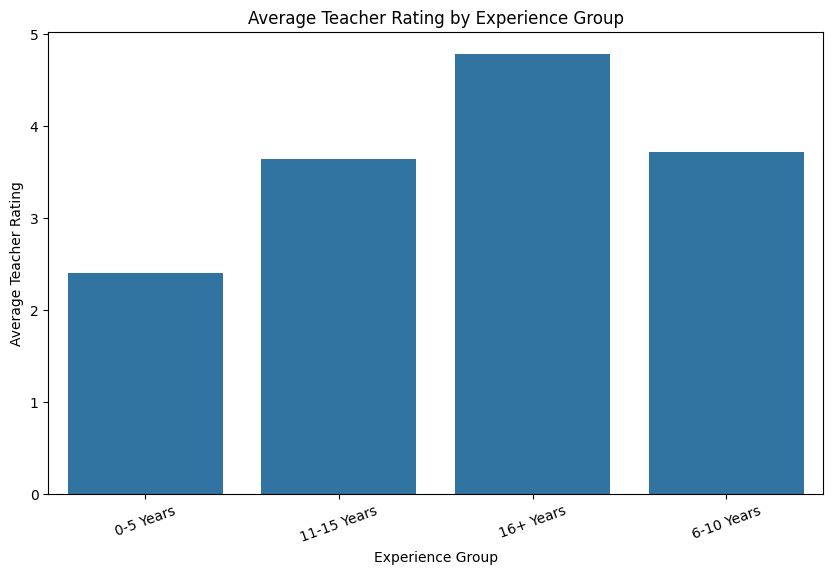

In [24]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=experience_summary,
    x="ExperienceGroup",
    y="mean"
)

plt.title("Average Teacher Rating by Experience Group")
plt.xlabel("Experience Group")
plt.ylabel("Average Teacher Rating")
plt.xticks(rotation=20)
plt.show()

In [25]:
# Install Streamlit and required packages

!pip -q install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 96.1 MB/s eta 0:00:00


In [26]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

st.set_page_config(
    page_title="EduPro Instructor Performance",
    page_icon="🎓",
    layout="wide"
)
# LOAD DATA
@st.cache_data
def load_data():

    teachers = pd.read_excel(
        "EduPro Online Platform(5).xlsx",
        sheet_name="Teachers"
    )

    courses = pd.read_excel(
        "EduPro Online Platform(5).xlsx",
        sheet_name="Courses"
    )

    transactions = pd.read_excel(
        "EduPro Online Platform(5).xlsx",
        sheet_name="Transactions"
    )

    df = transactions.merge(
        teachers,
        on="TeacherID",
        how="left"
    )

    df = df.merge(
        courses,
        on="CourseID",
        how="left"
    )

    return teachers, courses, transactions, df


teachers, courses, transactions, df = load_data()

# TITLE

st.title("🎓 EduPro Instructor Performance & Course Quality Dashboard")

st.markdown(
    """
    ### Instructor Performance and Course Quality Evaluation

    This dashboard provides data-driven analysis of:
    - Instructor performance
    - Teaching experience
    - Course quality
    - Instructor expertise
    - Course ratings
    - Enrollment performance
    """
)

# SIDEBAR FILTERS


st.sidebar.header("Dashboard Filters")

expertise_options = sorted(
    teachers["Expertise"].dropna().unique()
)

selected_expertise = st.sidebar.multiselect(
    "Select Expertise",
    expertise_options,
    default=expertise_options
)

category_options = sorted(
    courses["CourseCategory"].dropna().unique()
)

selected_category = st.sidebar.multiselect(
    "Select Course Category",
    category_options,
    default=category_options
)

level_options = sorted(
    courses["CourseLevel"].dropna().unique()
)

selected_level = st.sidebar.multiselect(
    "Select Course Level",
    level_options,
    default=level_options
)

# FILTER DATA

filtered_df = df[
    (df["Expertise"].isin(selected_expertise)) &
    (df["CourseCategory"].isin(selected_category)) &
    (df["CourseLevel"].isin(selected_level))
].copy()

# KPIs

avg_teacher_rating = filtered_df[
    "TeacherRating"
].mean()

avg_course_rating = filtered_df[
    "CourseRating"
].mean()

total_enrollments = filtered_df[
    "TransactionID"
].nunique()

total_instructors = filtered_df[
    "TeacherID"
].nunique()

total_courses = filtered_df[
    "CourseID"
].nunique()


col1, col2, col3, col4, col5 = st.columns(5)

col1.metric(
    "Average Teacher Rating",
    f"{avg_teacher_rating:.2f}"
)

col2.metric(
    "Average Course Rating",
    f"{avg_course_rating:.2f}"
)

col3.metric(
    "Total Enrollments",
    f"{total_enrollments:,}"
)

col4.metric(
    "Instructors",
    f"{total_instructors:,}"
)

col5.metric(
    "Courses",
    f"{total_courses:,}"
)


st.divider()

# INSTRUCTOR LEADERBOARD

st.header("🏆 Instructor Performance Leaderboard")

leaderboard = (
    filtered_df
    .groupby(
        [
            "TeacherID",
            "TeacherName",
            "Expertise"
        ]
    )
    .agg(
        TeacherRating=("TeacherRating", "first"),
        AverageCourseRating=("CourseRating", "mean"),
        Experience=("YearsOfExperience", "first"),
        Enrollments=("TransactionID", "count"),
        CoursesTaught=("CourseID", "nunique")
    )
    .reset_index()
)

leaderboard["OverallScore"] = (
    leaderboard["TeacherRating"] * 0.5 +
    leaderboard["AverageCourseRating"] * 0.5
)

leaderboard = leaderboard.sort_values(
    "OverallScore",
    ascending=False
)

st.dataframe(
    leaderboard,
    use_container_width=True
)

# EXPERIENCE VS TEACHER RATING

st.header("📈 Experience vs Teacher Rating")

fig1 = px.scatter(
    leaderboard,
    x="Experience",
    y="TeacherRating",
    size="Enrollments",
    color="Expertise",
    hover_name="TeacherName",
    title="Teaching Experience vs Teacher Rating"
)

st.plotly_chart(
    fig1,
    use_container_width=True
)

# TEACHER RATING VS COURSE RATING

st.header("⭐ Teacher Rating vs Course Rating")

teacher_course = (
    filtered_df
    .groupby(
        ["TeacherID", "TeacherName"]
    )
    .agg(
        TeacherRating=("TeacherRating", "first"),
        CourseRating=("CourseRating", "mean")
    )
    .reset_index()
)

fig2 = px.scatter(
    teacher_course,
    x="TeacherRating",
    y="CourseRating",
    hover_name="TeacherName",
    title="Teacher Rating vs Average Course Rating",
    trendline="ols"
)

st.plotly_chart(
    fig2,
    use_container_width=True
)

# COURSE QUALITY BY CATEGORY
st.header("📚 Course Quality by Category")

category_analysis = (
    filtered_df
    .groupby("CourseCategory")
    .agg(
        AverageRating=("CourseRating", "mean"),
        NumberOfCourses=("CourseID", "nunique")
    )
    .reset_index()
)

fig3 = px.bar(
    category_analysis,
    x="CourseCategory",
    y="AverageRating",
    text_auto=".2f",
    title="Average Course Rating by Category"
)

st.plotly_chart(
    fig3,
    use_container_width=True
)


# COURSE QUALITY HEATMAP
st.header("🔥 Course Quality Heatmap")

heatmap_data = pd.pivot_table(
    filtered_df,
    values="CourseRating",
    index="CourseCategory",
    columns="CourseLevel",
    aggfunc="mean"
)

fig4 = px.imshow(
    heatmap_data,
    text_auto=".2f",
    aspect="auto",
    title="Average Course Rating by Category and Level"
)

st.plotly_chart(
    fig4,
    use_container_width=True
)

# EXPERTISE ANALYSIS
st.header("👨‍🏫 Expertise-wise Performance")

expertise_analysis = (
    filtered_df
    .groupby("Expertise")
    .agg(
        AverageTeacherRating=("TeacherRating", "mean"),
        AverageCourseRating=("CourseRating", "mean"),
        AverageExperience=("YearsOfExperience", "mean"),
        TotalEnrollments=("TransactionID", "count")
    )
    .reset_index()
)

fig5 = px.bar(
    expertise_analysis,
    x="Expertise",
    y="AverageCourseRating",
    color="Expertise",
    text_auto=".2f",
    title="Course Quality by Instructor Expertise"
)

st.plotly_chart(
    fig5,
    use_container_width=True
)

# ENROLLMENT ANALYSIS

st.header("👥 Instructor Rating vs Enrollment")

fig6 = px.scatter(
    leaderboard,
    x="TeacherRating",
    y="Enrollments",
    size="AverageCourseRating",
    color="Expertise",
    hover_name="TeacherName",
    title="Instructor Rating vs Enrollment"
)

st.plotly_chart(
    fig6,
    use_container_width=True
)

# COURSE LEVEL ANALYSIS
st.header("🎯 Course Level Performance")

level_analysis = (
    filtered_df
    .groupby("CourseLevel")
    .agg(
        AverageRating=("CourseRating", "mean"),
        Enrollments=("TransactionID", "count")
    )
    .reset_index()
)

fig7 = px.bar(
    level_analysis,
    x="CourseLevel",
    y="AverageRating",
    text_auto=".2f",
    title="Average Rating by Course Level"
)

st.plotly_chart(
    fig7,
    use_container_width=True
)

# FOOTER
st.divider()

st.markdown(
    """
    ### Conclusion

    The EduPro dashboard provides a data-driven framework for
    evaluating instructor effectiveness and course quality.

    The analysis helps identify:
    - High-performing instructors
    - Low-performing instructors
    - Strong expertise areas
    - High-quality course categories
    - Relationship between experience and performance
    - Relationship between instructor ratings and enrollments
    """
)

Writing app.py


In [27]:
from google.colab import files

uploaded = files.upload()

Saving EduPro Online Platform.xlsx to EduPro Online Platform (1).xlsx


In [46]:
!cp "EduPro Online Platform.xlsx" "EduPro Online Platform(5).xlsx"
print("Done")

Done


In [47]:
!streamlit run app.py &>/content/logs.txt &

In [48]:
import os

if os.path.exists("app.py"):
    print("✅ app.py created successfully")
    print("File size:", os.path.getsize("app.py"), "bytes")
else:
    print("❌ app.py was not created")

✅ app.py created successfully
File size: 8879 bytes


In [49]:
!pkill -f streamlit || true

^C


In [50]:
import time
import os

time.sleep(5)

print("========== STREAMLIT LOG ==========")

if os.path.exists("/content/streamlit.log"):
    with open("/content/streamlit.log", "r") as f:
        print(f.read())
else:
    print("Log file not found.")

========== STREAMLIT LOG ==========


2026-09-11 11:11:40.962 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.237.7.17:8501

────────────────────────── Traceback (most recent call last) ───────────────────────────
  /usr/local/lib/python3.13/dist-packages/streamlit/runtime/scriptrunner/exec_code.py:  
  136 in exec_func_with_error_handling                                                  
                                                                                        
  /usr/local/lib/python3.13/dist-packages/streamlit/runtime/scriptrunner/script_runner  
  .py:827 in code_to_exec                                                               
                                                                                        
  /content/app.py:51 in <module>                                                        
               

In [51]:
from pyngrok import ngrok

In [68]:
import os
import time
import requests

# Stop old Streamlit processes
os.system("pkill -f streamlit || true")

time.sleep(2)

# Start Streamlit again
os.system(
    "nohup streamlit run app.py "
    "--server.address=0.0.0.0 "
    "--server.port=8501 "
    "> /content/streamlit.log 2>&1 &"
)

# Give Streamlit time to start
time.sleep(8)

# Check Streamlit
try:
    response = requests.get(
        "http://localhost:8501",
        timeout=10
    )

    print("======================================")
    print("STREAMLIT STATUS")
    print("======================================")
    print("Status Code:", response.status_code)

    if response.status_code == 200:
        print("✅ Streamlit is running successfully!")
        print("✅ Port 8501 is active.")
    else:
        print("⚠️ Streamlit returned:", response.status_code)

except Exception as e:
    print("❌ Streamlit is NOT running.")
    print("Error:", e)

STREAMLIT STATUS
Status Code: 200
✅ Streamlit is running successfully!
✅ Port 8501 is active.


In [55]:


print("========== STREAMLIT LOG ==========")

if os.path.exists("/content/streamlit.log"):
    with open("/content/streamlit.log", "r") as f:
        log = f.read()

    print(log[-5000:])
else:
    print("❌ streamlit.log not found")

========== STREAMLIT LOG ==========


2026-09-11 11:25:45.131 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.237.7.17:8501




In [56]:


from pyngrok import ngrok

# Close old tunnels
ngrok.kill()

# Create new tunnel
public_url = ngrok.connect(8501)

print("======================================")
print("🎓 EDUPRO DASHBOARD")
print("======================================")
print("✅ Dashboard is live!")
print()
print("🌐 PUBLIC URL:")
print(public_url)

🎓 EDUPRO DASHBOARD
✅ Dashboard is live!

🌐 PUBLIC URL:
NgrokTunnel: "https://upward-silencer-botany.ngrok-free.dev" -> "http://localhost:8501"


In [67]:
import pandas as pd
import numpy as np

print("=" * 65)
print("       EDUPRO FINAL RESULTS & BUSINESS INSIGHTS")
print("=" * 65)

# 1. PROJECT SUMMARY


print("\n📊 PROJECT SUMMARY")
print("-" * 45)

print("Total Instructors :", teachers["TeacherID"].nunique())
print("Total Courses     :", courses["CourseID"].nunique())
print("Total Transactions:", transactions["TransactionID"].nunique())

# 2. OVERALL RATINGS

print("\n⭐ OVERALL RATING ANALYSIS")
print("-" * 45)

avg_teacher_rating = teachers["TeacherRating"].mean()
avg_course_rating = courses["CourseRating"].mean()

print(f"Average Teacher Rating : {avg_teacher_rating:.2f}")
print(f"Average Course Rating  : {avg_course_rating:.2f}")

# 3. EXPERIENCE


print("\n👨\u200d🏫 EXPERIENCE ANALYSIS")
print("-" * 45)

avg_experience = teachers["YearsOfExperience"].mean()

print(f"Average Teaching Experience : {avg_experience:.2f} years")


# 4. COURSE ENROLLMENTS


course_enrollment = (
    transactions
    .groupby("CourseID")
    .size()
    .reset_index(name="Enrollments")
)

course_analysis = courses.merge(
    course_enrollment,
    on="CourseID",
    how="left"
)

course_analysis["Enrollments"] = (
    course_analysis["Enrollments"].fillna(0)
)


# 5. INSTRUCTOR PERFORMANCE

# Create master_df by merging transactions, teachers, and courses
master_df = transactions.merge(teachers, on='TeacherID', how='left')
master_df = master_df.merge(courses, on='CourseID', how='left')

# Use master_df created earlier in the notebook
teacher_data = master_df.copy()

print("\n🔎 Available columns in master data:")
print(teacher_data.columns.tolist())

# Find teacher name column
if "TeacherName" in teacher_data.columns:
    teacher_name_col = "TeacherName"
elif "TeacherName_x" in teacher_data.columns:
    teacher_name_col = "TeacherName_x"
else:
    teacher_name_col = None

# Find teacher ID column
possible_id_columns = [
    "TeacherID",
    "TeacherID_x",
    "Teacher_ID",
    "InstructorID",
    "Instructor_ID"
]

teacher_id_col = None

for col in possible_id_columns:
    if col in teacher_data.columns:
        teacher_id_col = col
        break


# 6. BUILD INSTRUCTOR PERFORMANCE

if teacher_id_col is not None and teacher_name_col is not None:

    instructor_performance = (
        teacher_data
        .groupby(
            [
                teacher_id_col,
                teacher_name_col
            ],
            as_index=False
        )
        .agg(
            AverageCourseRating=("CourseRating", "mean"),
            TotalEnrollments=("TransactionID", "count"),
            TotalRevenue=("Amount", "sum") # Changed from "Revenue" to "Amount"
        )
    )

    # Rename columns
    instructor_performance = instructor_performance.rename(
        columns={
            teacher_id_col: "TeacherID",
            teacher_name_col: "TeacherName"
        }
    )

    # Add teacher information
    instructor_performance = instructor_performance.merge(
        teachers[
            [
                "TeacherID",
                "Expertise",
                "TeacherRating",
                "YearsOfExperience"
            ]
        ],
        on="TeacherID",
        how="left"
    )

else:

    print("\n⚠️ TeacherID/TeacherName not available in master_df.")
    print("Using teacher information from Teachers table.")

    instructor_performance = teachers[
        [
            "TeacherID",
            "TeacherName",
            "Expertise",
            "TeacherRating",
            "YearsOfExperience"
        ]
    ].copy()

    instructor_performance["AverageCourseRating"] = (
        instructor_performance["TeacherRating"]
    )

    instructor_performance["TotalEnrollments"] = 0
    instructor_performance["TotalRevenue"] = 0


# 7. HANDLE MISSING VALUES


instructor_performance["AverageCourseRating"] = (
    instructor_performance["AverageCourseRating"]
    .fillna(0)
)

instructor_performance["TotalEnrollments"] = (
    instructor_performance["TotalEnrollments"]
    .fillna(0)
)

instructor_performance["TotalRevenue"] = (
    instructor_performance["TotalRevenue"]
    .fillna(0)
)


# 8. NUMBER OF COURSES


if teacher_id_col is not None:

    course_count = (
        teacher_data
        .groupby(teacher_id_col)["CourseID"]
        .nunique()
        .reset_index(name="NumberOfCourses")
    )

    course_count = course_count.rename(
        columns={teacher_id_col: "TeacherID"}
    )

    instructor_performance = instructor_performance.merge(
        course_count,
        on="TeacherID",
        how="left"
    )

else:

    instructor_performance["NumberOfCourses"] = 0

instructor_performance["NumberOfCourses"] = (
    instructor_performance["NumberOfCourses"]
    .fillna(0)
)


# 9. PERFORMANCE SCORE

max_enrollment = instructor_performance[
    "TotalEnrollments"
].max()

max_experience = instructor_performance[
    "YearsOfExperience"
].max()

if max_enrollment > 0:
    enrollment_score = (
        instructor_performance["TotalEnrollments"]
        / max_enrollment
    ) * 5
else:
    enrollment_score = 0

if max_experience > 0:
    experience_score = (
        instructor_performance["YearsOfExperience"]
        / max_experience
    ) * 5
else:
    experience_score = 0

instructor_performance["PerformanceScore"] = (
    instructor_performance["TeacherRating"] * 0.40
    + instructor_performance["AverageCourseRating"] * 0.30
    + enrollment_score * 0.20
    + experience_score * 0.10
)


# 10. RANK INSTRUCTORS

instructor_performance = (
    instructor_performance
    .sort_values(
        "PerformanceScore",
        ascending=False
    )
    .reset_index(drop=True)
)

instructor_performance["Rank"] = (
    instructor_performance.index + 1
)


# 11. TOP 10


print("\n🏆 TOP 10 INSTRUCTORS")
print("-" * 45)

display(
    instructor_performance.head(10)[
        [
            "Rank",
            "TeacherName",
            "Expertise",
            "TeacherRating",
            "AverageCourseRating",
            "YearsOfExperience",
            "TotalEnrollments",
            "NumberOfCourses",
            "PerformanceScore"
        ]
    ]
)


# 12. BOTTOM 10


print("\n⚠️ BOTTOM 10 INSTRUCTORS")
print("-" * 45)

bottom_10 = (
    instructor_performance
    .sort_values("PerformanceScore")
    .head(10)
)

display(
    bottom_10[
        [
            "Rank",
            "TeacherName",
            "Expertise",
            "TeacherRating",
            "AverageCourseRating",
            "YearsOfExperience",
            "TotalEnrollments",
            "NumberOfCourses",
            "PerformanceScore"
        ]
    ]
)


# 13. COURSE CATEGORY

print("\n📚 COURSE CATEGORY PERFORMANCE")
print("-" * 45)

category_results = (
    course_analysis
    .groupby("CourseCategory")
    .agg(
        AverageCourseRating=("CourseRating", "mean"),
        TotalEnrollments=("Enrollments", "sum"),
        NumberOfCourses=("CourseID", "nunique")
    )
    .reset_index()
    .sort_values(
        "AverageCourseRating",
        ascending=False
    )
)

display(category_results)


# 14. EXPERTISE ANALYSIS


print("\n🎯 EXPERTISE-WISE PERFORMANCE")
print("-" * 45)

expertise_results = (
    instructor_performance
    .groupby("Expertise")
    .agg(
        AverageTeacherRating=("TeacherRating", "mean"),
        AverageCourseRating=("AverageCourseRating", "mean"),
        AverageExperience=("YearsOfExperience", "mean"),
        TotalEnrollments=("TotalEnrollments", "sum"),
        NumberOfInstructors=("TeacherID", "nunique")
    )
    .reset_index()
    .sort_values(
        "AverageTeacherRating",
        ascending=False
    )
)

display(expertise_results)


# 15. COURSE LEVEL


print("\n📈 COURSE LEVEL PERFORMANCE")
print("-" * 45)

level_results = (
    course_analysis
    .groupby("CourseLevel")
    .agg(
        AverageRating=("CourseRating", "mean"),
        TotalEnrollments=("Enrollments", "sum"),
        NumberOfCourses=("CourseID", "nunique")
    )
    .reset_index()
    .sort_values(
        "AverageRating",
        ascending=False
    )
)

display(level_results)



best_instructor = instructor_performance.iloc[0]["TeacherName"]
best_category = category_results.iloc[0]["CourseCategory"]
best_expertise = expertise_results.iloc[0]["Expertise"]
best_level = level_results.iloc[0]["CourseLevel"]

print("\n" + "=" * 65)
print("                 FINAL BUSINESS INSIGHTS")
print("=" * 65)

print(f"""
🏆 Best Performing Instructor
   → {best_instructor}

📚 Highest Rated Course Category
   → {best_category}

🎯 Top Performing Expertise
   → {best_expertise}

📈 Highest Rated Course Level
   → {best_level}

⭐ Average Teacher Rating
   → {avg_teacher_rating:.2f}

⭐ Average Course Rating
   → {avg_course_rating:.2f}

👨\u200d🏫 Average Teaching Experience
   → {avg_experience:.2f} years
""")

print("=" * 65)
print("=" * 65)

       EDUPRO FINAL RESULTS & BUSINESS INSIGHTS

📊 PROJECT SUMMARY
---------------------------------------------
Total Instructors : 60
Total Courses     : 60
Total Transactions: 10000

⭐ OVERALL RATING ANALYSIS
---------------------------------------------
Average Teacher Rating : 3.12
Average Course Rating  : 3.10

👨‍🏫 EXPERIENCE ANALYSIS
---------------------------------------------
Average Teaching Experience : 6.28 years

🔎 Available columns in master data:
['TransactionID', 'UserID', 'CourseID', 'TransactionDate', 'Amount', 'PaymentMethod', 'TeacherID', 'TeacherName', 'Age', 'Gender', 'Expertise', 'YearsOfExperience', 'TeacherRating', 'ExperienceGroup', 'CourseName', 'CourseCategory', 'CourseType', 'CourseLevel', 'CoursePrice', 'CourseDuration', 'CourseRating']

🏆 TOP 10 INSTRUCTORS
---------------------------------------------


,Rank,TeacherName,Expertise,TeacherRating,AverageCourseRating,YearsOfExperience,TotalEnrollments,NumberOfCourses,PerformanceScore
0,1,Yolanda Levine,Machine Learning,4.97,3.079252,21,3061,55,4.349276
1,2,Kimberly Miller,Cybersecurity,4.58,3.147997,24,3025,55,4.264638
2,3,Aaron Kirby,Marketing,4.29,3.646667,9,120,9,3.036703
3,4,Jill Day,Digital Marketing,4.14,3.708824,9,68,9,2.978362
4,5,Kari Pierce,Project Management,4.28,3.246237,11,93,8,2.945420
5,6,Michael Kim,Digital Marketing,4.22,3.582807,6,57,8,2.906463
6,7,Wesley Garcia,Design,4.04,3.247956,12,137,8,2.885143
7,8,Debra Escobar,Finance,4.39,3.054444,8,117,10,2.877223
8,9,Shelby Patrick,Artificial Intelligence,4.28,3.146304,7,46,9,2.816752
9,10,Steven Walker,Data Science,3.54,3.267218,15,133,9,2.752115



⚠️ BOTTOM 10 INSTRUCTORS
---------------------------------------------


,Rank,TeacherName,Expertise,TeacherRating,AverageCourseRating,YearsOfExperience,TotalEnrollments,NumberOfCourses,PerformanceScore
59,60,John Williams,Project Management,1.05,2.960735,1,68,14,1.351269
58,59,Timothy Bailey,Business,1.06,2.765155,3,161,16,1.368644
57,58,Emily Gutierrez,Web Development,1.07,2.800536,5,56,17,1.390622
56,57,Amber Torres,Design,1.56,3.107627,4,59,15,1.658896
55,56,Brenda Mclean,Digital Marketing,1.39,3.382174,4,46,15,1.669013
54,55,Laurie Michael,Artificial Intelligence,1.55,3.149774,3,133,13,1.670882
53,54,John Obrien,Design,1.77,3.116349,2,63,14,1.705153
52,53,Brenda Mercer,Cybersecurity,1.86,3.073354,1,164,15,1.740417
51,52,Brad Griffin,Design,1.79,3.168154,4,65,14,1.771014
50,51,Justin Pham,Web Development,2.17,2.881458,4,48,15,1.831452



📚 COURSE CATEGORY PERFORMANCE
---------------------------------------------


...


🎯 EXPERTISE-WISE PERFORMANCE
---------------------------------------------


,Expertise,AverageTeacherRating,AverageCourseRating,AverageExperience,TotalEnrollments,NumberOfInstructors
8,Marketing,4.290000,3.646667,9.000000,120,1
7,Machine Learning,4.234000,2.775056,8.800000,3303,5
9,Programming,3.950000,2.980488,9.000000,123,1
2,Cybersecurity,3.468889,3.038318,8.000000,3450,9
6,Finance,3.265000,3.165917,5.333333,410,6
0,Artificial Intelligence,3.173333,3.155289,5.500000,389,6
5,Digital Marketing,3.050000,3.546759,5.363636,479,11
3,Data Science,3.030000,3.282659,6.200000,432,5
10,Project Management,2.664000,3.082780,6.200000,368,5
11,Web Development,2.514000,2.944794,4.000000,344,5



📈 COURSE LEVEL PERFORMANCE
---------------------------------------------


,CourseLevel,AverageRating,TotalEnrollments,NumberOfCourses
2,Intermediate,3.322778,2952,18
1,Beginner,3.189048,3573,21
0,Advanced,2.813810,3475,21



                 FINAL BUSINESS INSIGHTS

🏆 Best Performing Instructor
   → Yolanda Levine

📚 Highest Rated Course Category
   → Marketing

🎯 Top Performing Expertise
   → Marketing

📈 Highest Rated Course Level
   → Intermediate

⭐ Average Teacher Rating
   → 3.12

⭐ Average Course Rating
   → 3.10

👨‍🏫 Average Teaching Experience
   → 6.28 years



In [66]:

import pandas as pd
from google.colab import files

print("=" * 65)
print("       CREATING FINAL EDUPRO EXCEL REPORT")
print("=" * 65)



kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Instructors",
        "Total Courses",
        "Total Transactions",
        "Average Teacher Rating",
        "Average Course Rating",
        "Average Teaching Experience"
    ],
    "Value": [
        teachers["TeacherID"].nunique(),
        courses["CourseID"].nunique(),
        transactions["TransactionID"].nunique(),
        round(teachers["TeacherRating"].mean(), 2),
        round(courses["CourseRating"].mean(), 2),
        round(teachers["YearsOfExperience"].mean(), 2)
    ]
})



instructor_report = instructor_performance[
    [
        "Rank",
        "TeacherID",
        "TeacherName",
        "Expertise",
        "TeacherRating",
        "AverageCourseRating",
        "YearsOfExperience",
        "TotalEnrollments",
        "NumberOfCourses",
        "TotalRevenue",
        "PerformanceScore"
    ]
].copy()



course_report = course_analysis.copy()

# Keep useful columns only
course_columns = [
    "CourseID",
    "CourseName",
    "CourseCategory",
    "CourseType",
    "CourseLevel",
    "CourseRating",
    "CoursePrice",
    "CourseDuration",
    "Enrollments"
]

# Keep only columns that actually exist
course_columns = [
    col for col in course_columns
    if col in course_report.columns
]

course_report = course_report[course_columns]



expertise_report = expertise_results.copy()



category_report = category_results.copy()



level_report = level_results.copy()



top_10_report = instructor_performance.head(10).copy()



bottom_10_report = (
    instructor_performance
    .sort_values("PerformanceScore", ascending=True)
    .head(10)
    .copy()
)



file_name = "EduPro_Final_Project_Report.xlsx"

with pd.ExcelWriter(
    file_name,
    engine="openpyxl"
) as writer:

    kpi_summary.to_excel(
        writer,
        sheet_name="KPI Summary",
        index=False
    )

    instructor_report.to_excel(
        writer,
        sheet_name="Instructor Performance",
        index=False
    )

    top_10_report.to_excel(
        writer,
        sheet_name="Top 10 Instructors",
        index=False
    )

    bottom_10_report.to_excel(
        writer,
        sheet_name="Bottom 10 Instructors",
        index=False
    )

    course_report.to_excel(
        writer,
        sheet_name="Course Quality",
        index=False
    )

    expertise_report.to_excel(
        writer,
        sheet_name="Expertise Analysis",
        index=False
    )

    category_report.to_excel(
        writer,
        sheet_name="Category Analysis",
        index=False
    )

    level_report.to_excel(
        writer,
        sheet_name="Course Level Analysis",
        index=False
    )



print("\n✅ Excel report created successfully!")
print("\nFile name:")
print(file_name)

print("\n📁 Sheets included:")
print("1. KPI Summary")
print("2. Instructor Performance")
print("3. Top 10 Instructors")
print("4. Bottom 10 Instructors")
print("5. Course Quality")
print("6. Expertise Analysis")
print("7. Category Analysis")
print("8. Course Level Analysis")

print("\n" + "=" * 65)
print("=" * 65)



files.download(file_name)

       CREATING FINAL EDUPRO EXCEL REPORT

✅ Excel report created successfully!

File name:
EduPro_Final_Project_Report.xlsx

📁 Sheets included:
1. KPI Summary
2. Instructor Performance
3. Top 10 Instructors
4. Bottom 10 Instructors
5. Course Quality
6. Expertise Analysis
7. Category Analysis
8. Course Level Analysis



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [65]:


print("=" * 70)
print("        EDUPRO - FINAL CONCLUSION & RECOMMENDATIONS")
print("=" * 70)


# 1. FINAL PROJECT SUMMARY

print("\n📌 PROJECT SUMMARY")
print("-" * 50)

print("""
Project Title:
Instructor Performance and Course Quality Evaluation on EduPro

Project Objective:
To analyze instructor performance, course quality, ratings,
experience, enrollments and identify high-performing areas
using data analytics and visualization.
""")

# 2. KEY RESULTS


print("\n📊 KEY RESULTS")
print("-" * 50)

print(f"Total Instructors       : {teachers['TeacherID'].nunique()}")
print(f"Total Courses           : {courses['CourseID'].nunique()}")
print(f"Total Transactions      : {transactions['TransactionID'].nunique()}")
print(f"Average Teacher Rating  : {teachers['TeacherRating'].mean():.2f}")
print(f"Average Course Rating   : {courses['CourseRating'].mean():.2f}")
print(f"Average Experience      : {teachers['YearsOfExperience'].mean():.2f} years"}

# 3. BEST INSTRUCTOR


best_instructor = instructor_performance.iloc[0]

print("\n🏆 BEST PERFORMING INSTRUCTOR")
print("-" * 50)

print("Instructor Name :", best_instructor["TeacherName"])
print("Expertise       :", best_instructor["Expertise"])
print("Teacher Rating  :", round(best_instructor["TeacherRating"], 2))
print("Course Rating   :", round(best_instructor["AverageCourseRating"], 2))
print("Experience      :", best_instructor["YearsOfExperience"])
print("Enrollments     :", int(best_instructor["TotalEnrollments"]))
print("Performance Score:", round(best_instructor["PerformanceScore"], 2))


# 4. BEST CATEGORY

best_category = category_results.iloc[0]

print("\n📚 BEST COURSE CATEGORY")
print("-" * 50)

print("Category        :", best_category["CourseCategory"])
print("Average Rating  :", round(best_category["AverageCourseRating"], 2))
print("Enrollments     :", int(best_category["TotalEnrollments"]))

# 5. BEST EXPERTISE


best_expertise = expertise_results.iloc[0]

print("\n🎯 BEST EXPERTISE AREA")
print("-" * 50)

print("Expertise       :", best_expertise["Expertise"])
print("Teacher Rating  :", round(best_expertise["AverageTeacherRating"], 2))
print("Course Rating   :", round(best_expertise["AverageCourseRating"], 2))
print("Experience      :", round(best_expertise["AverageExperience"], 2))
print("Enrollments     :", int(best_expertise["TotalEnrollments"]))


# 6. RECOMMENDATIONS


print("\n💡 BUSINESS RECOMMENDATIONS")
print("-" * 50)

recommendations = [
    "1. Recognize and reward high-performing instructors.",

    "2. Provide additional training and mentoring for "
    "low-performing instructors.",

    "3. Improve courses with ratings below the overall "
    "course-rating average.",

    "4. Analyze student enrollment patterns to identify "
    "popular courses and topics.",

    "5. Encourage instructors to improve course content, "
    "teaching quality and student engagement.",

    "6. Regularly monitor instructor and course KPIs "
    "through the Streamlit dashboard.",

    "7. Use learner feedback and ratings for continuous "
    "course improvement.",

    "8. Focus marketing efforts on high-quality courses "
    "with strong enrollment potential."
]

for recommendation in recommendations:
    print("✅", recommendation)


# 7. PROJECT CONCLUSION


print("\n" + "=" * 70)
print("                    PROJECT CONCLUSION")
print("=" * 70)

print("""
The EduPro Instructor Performance and Course Quality Evaluation
project successfully analyzed instructor and course-related data.

The analysis identified differences in instructor performance,
course ratings, teaching experience, course categories,
expertise areas and student enrollments.

The results can help EduPro management make data-driven decisions
regarding instructor development, course improvement, student
engagement and business strategy.

The Streamlit dashboard provides an interactive way to monitor
important KPIs and performance indicators.

Overall, this project demonstrates how Python, Pandas,
Matplotlib, Seaborn and Streamlit can be used to transform
educational data into useful business insights.
""")

print("=" * 70)
print("=" * 70)

        EDUPRO - FINAL CONCLUSION & RECOMMENDATIONS

📌 PROJECT SUMMARY
--------------------------------------------------

Project Title:
Instructor Performance and Course Quality Evaluation on EduPro

Project Objective:
To analyze instructor performance, course quality, ratings,
experience, enrollments and identify high-performing areas
using data analytics and visualization.


📊 KEY RESULTS
--------------------------------------------------
Total Instructors       : 60
Total Courses           : 60
Total Transactions      : 10000
Average Teacher Rating  : 3.12
Average Course Rating   : 3.10
Average Experience      : 6.28 years

🏆 BEST PERFORMING INSTRUCTOR
--------------------------------------------------
Instructor Name : Yolanda Levine
Expertise       : Machine Learning
Teacher Rating  : 4.97
Course Rating   : 3.08
Experience      : 21
Enrollments     : 3061
Performance Score: 4.35

📚 BEST COURSE CATEGORY
--------------------------------------------------
Category        : Marketin